<a href="https://colab.research.google.com/github/vedrode2011-collab/TFIM-trotter-experiment/blob/main/ZX_Reduction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setting up account


In [ ]:
!pip install qiskit qiskit-ibm-runtime

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    token="PjKgjVYum4l7n31ZdAknhRaYIEeVHb5ZlorhlpZTVYaq",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/127e1f82f8f24dfc857d31616b76107b:97bb2674-daaf-4b07-bfe3-541a9d43f593::",
    overwrite=True,
)

# TFIM Trotter Circuit: ZX-Calculus Reduction, Equivalence Checking, and Noisy-Hardware Magnetization Accuracy Comparison

In [ ]:
!pip install qiskit qiskit_aer qiskit-ibm-runtime pyzx pylatexenc

In [ ]:
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import pyzx as zx
from qiskit import QuantumCircuit, qasm2
from qiskit.quantum_info import Operator, Statevector, Pauli
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeKingston
from qiskit.visualization import plot_histogram
from IPython.display import display

## 1. Build the TFIM Trotter circuit (baseline)

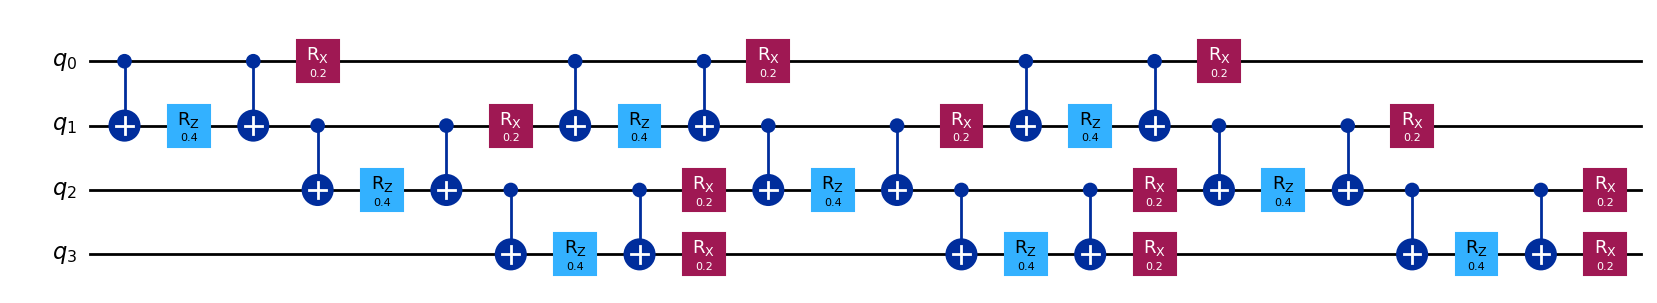

In [ ]:
num_qubits = 4
J = 1.0
g = 0.5
dt = 0.2          # small Trotter time step
steps = 3         # repetition amount

def build_tfim_trotter_circuit(num_qubits, J, g, dt, steps):
    qc = QuantumCircuit(num_qubits)
    for _ in range(steps):
        # ZZ interaction layer
        for i in range(num_qubits - 1):
            qc.cx(i, i + 1)
            qc.rz(2 * J * dt, i + 1)
            qc.cx(i, i + 1)
        # Transverse field layer
        for i in range(num_qubits):
            qc.rx(2 * g * dt, i)
    return qc

qc_baseline = build_tfim_trotter_circuit(num_qubits, J, g, dt, steps)
qc_baseline.draw("mpl")

## 2. Reduction functions

Each function does: `qc -> qasm -> pyzx graph -> reduce -> extract -> qasm -> qc`,
then checks equivalence against the baseline circuit before returning.
Raises immediately if the check fails.

The extractor differs by reduction type:
- `teleport_reduce` leaves the graph CIRCUIT-LIKE, so it converts back directly via `zx.Circuit.from_graph()`.
- `full_reduce` changes the graph into a general GRAPH-LIKE ZX-diagram (only green spiders plus Hadamard edges),
  which requires the special `zx.extract_circuit()` method to convert back into a circuit.

Using the wrong one raises an error.

In [ ]:
def circuits_equivalent(qc1, qc2):
    sv1 = Statevector.from_instruction(qc1)
    sv2 = Statevector.from_instruction(qc2)
    return sv1 == sv2


def teleport_reduce_circuit(qc):
    qasm_str = qasm2.dumps(qc)
    graph = zx.Circuit.from_qasm(qasm_str).to_graph()
    zx.teleport_reduce(graph)
    extracted = zx.Circuit.from_graph(graph)
    qc_out = QuantumCircuit.from_qasm_str(extracted.to_qasm())

    if not circuits_equivalent(qc_baseline, qc_out):
        raise ValueError("teleport_reduce output is NOT equal to baseline circuit")
    return qc_out


def full_reduce_circuit(qc):
    qasm_str = qasm2.dumps(qc)
    graph = zx.Circuit.from_qasm(qasm_str).to_graph()
    zx.full_reduce(graph)
    extracted = zx.extract_circuit(graph.copy())
    qc_out = QuantumCircuit.from_qasm_str(extracted.to_qasm())

    if not circuits_equivalent(qc_baseline, qc_out):
        raise ValueError("full_reduce output is NOT equal to baseline circuit")
    return qc_out


# Run the two reductions, each checked against the baseline as it's produced
qc_careful = teleport_reduce_circuit(qc_baseline)
print("teleport_reduce: equivalence check passed.")

qc_aggressive = full_reduce_circuit(qc_baseline)
print("full_reduce: equivalence check passed.")

teleport_reduce: equivalence check passed.
full_reduce: equivalence check passed.


## 3. Pre-flight metrics (before running anything)\n\nTotal gates, two-qubit gates, T-count, depth — for all three versions.

In [ ]:
def circuit_metrics(qc):
    ops = qc.count_ops()
    total_gates = sum(ops.values())
    two_qubit_gates = sum(v for k, v in ops.items() if k in ("cx", "cz", "swap", "ecr"))

    # T-count via the ZX-graph representation (counts non-Clifford phase spiders)
    qasm_str = qasm2.dumps(qc)
    graph = zx.Circuit.from_qasm(qasm_str).to_graph()
    tcount = zx.tcount(graph)

    return {
        "total_gates": total_gates,
        "two_qubit_gates": two_qubit_gates,
        "tcount": tcount,
        "depth": qc.depth(),
    }

versions = {
    "baseline": qc_baseline,
    "careful": qc_careful,
    "aggressive": qc_aggressive,
}

print("--- Pre-flight circuit metrics ---")
for name, circ in versions.items():
    m = circuit_metrics(circ)
    print(name, "total_gates=", m["total_gates"], "two_qubit_gates=", m["two_qubit_gates"],
          "tcount=", m["tcount"], "depth=", m["depth"])

--- Pre-flight circuit metrics ---
baseline total_gates= 39 two_qubit_gates= 18 tcount= 21 depth= 24
careful total_gates= 39 two_qubit_gates= 18 tcount= 21 depth= 24
aggressive total_gates= 89 two_qubit_gates= 36 tcount= 21 depth= 61


## 4. Backend setup

One switch controls everything downstream: `backend_mode` is either `"fake"` or `"real"`.
This replaces the old separate scratch section (which referenced an undefined `ManilaV2()`,
and was later pinned to the now-retired `ibm_manila`) with a single, consistent path.
The real backend is pinned by name to `ibm_kingston`
(not "least busy") so results stay directly comparable to `FakeKingston` run after run.

In [ ]:
# Choose which backend to run on: "fake" or "real"
backend_mode = "fake"   # switch to "real" once validated

if backend_mode == "fake":
    backend = FakeKingston()
else:
    service = QiskitRuntimeService()
    backend = service.backend("ibm_kingston")   # pinned by name, not least_busy

print(f"Using backend: {backend.name} (mode={backend_mode})")

pm = generate_preset_pass_manager(optimization_level=1, backend=backend)

shots_per_run = 4000
num_repetitions = 3

Using backend: fake_kingston (mode=fake)


## 5. Reusable function: run a set of circuits on a given backend

Same code path for fake and real hardware. Each circuit (baseline, careful, aggressive)
is transpiled specifically for the target backend's native gate set — this is the
"different hardware speaks a different language" step — then run, with counts and
pre-flight metrics stored together.

In [ ]:
def run_versions_on_backend(versions, backend, shots=4000):
    pm_local = generate_preset_pass_manager(optimization_level=1, backend=backend)
    sampler = Sampler(mode=backend)
    results = {}

    for name, circ in versions.items():
        circ_with_measurement = circ.copy()
        circ_with_measurement.measure_all()
        isa_circ = pm_local.run(circ_with_measurement)

        job = sampler.run([isa_circ], shots=shots)
        counts = job.result()[0].data.meas.get_counts()

        results[name] = {
            "counts": counts,
            "metrics": circuit_metrics(circ),
        }
    return results

## 6. Run baseline, careful, and aggressive on BOTH the fake and the real Kingston backend\n\nUsing the identical function for both, so the comparison is apples-to-apples.

In [ ]:
fake_backend = FakeKingston()
fake_results = run_versions_on_backend(versions, fake_backend, shots=shots_per_run)

service = QiskitRuntimeService()
real_backend = service.backend("ibm_kingston")
real_results = run_versions_on_backend(versions, real_backend, shots=shots_per_run)

/tmp/ipykernel_1268/3988775956.py:3: DeprecationWarning: The SamplerV2 class is deprecated as of qiskit-ibm-runtime 0.50.0 and will be removed no sooner than 3 months after the release date. `qiskit_ibm_runtime.executor_sampler.Sampler` provides a new Sampler implementation that runs all the pre- and post-processing in the client side. The top-level `qiskit_ibm_runtime.Sampler` import will be updated to point to the client-side sampler in an upcoming release, with the legacy Sampler being available until the deprecation is completed.
  sampler = Sampler(mode=backend)
/tmp/ipykernel_1268/3988775956.py:3: DeprecationWarning: The SamplerV2 class is deprecated as of qiskit-ibm-runtime 0.50.0 and will be removed no sooner than 3 months after the release date. `qiskit_ibm_runtime.executor_sampler.Sampler` provides a new Sampler implementation that runs all the pre- and post-processing in the client side. The top-level `qiskit_ibm_runtime.Sampler` import will be updated to point to the client

# To take from job ID


In [ ]:
def retrieve_results_from_job_ids(job_ids, versions):
    service = QiskitRuntimeService()
    results = {}
    for name, jid in job_ids.items():
        job = service.job(jid)
        result = job.result()
        counts = result[0].data.meas.get_counts()
        results[name] = {
            "counts": counts,
            "metrics": circuit_metrics(versions[name]),
        }
    return results

In [ ]:
saved_job_ids = {
    "baseline": "dani9678gn2s739mmcv0",
    "careful": "dani97o2fm4c73f48ic0",
    "aggressive": "dani99lr85ps73fe3dog",
}

real_results = retrieve_results_from_job_ids(saved_job_ids, versions)

## 7. Histograms: fake vs. real, for all three circuit versions

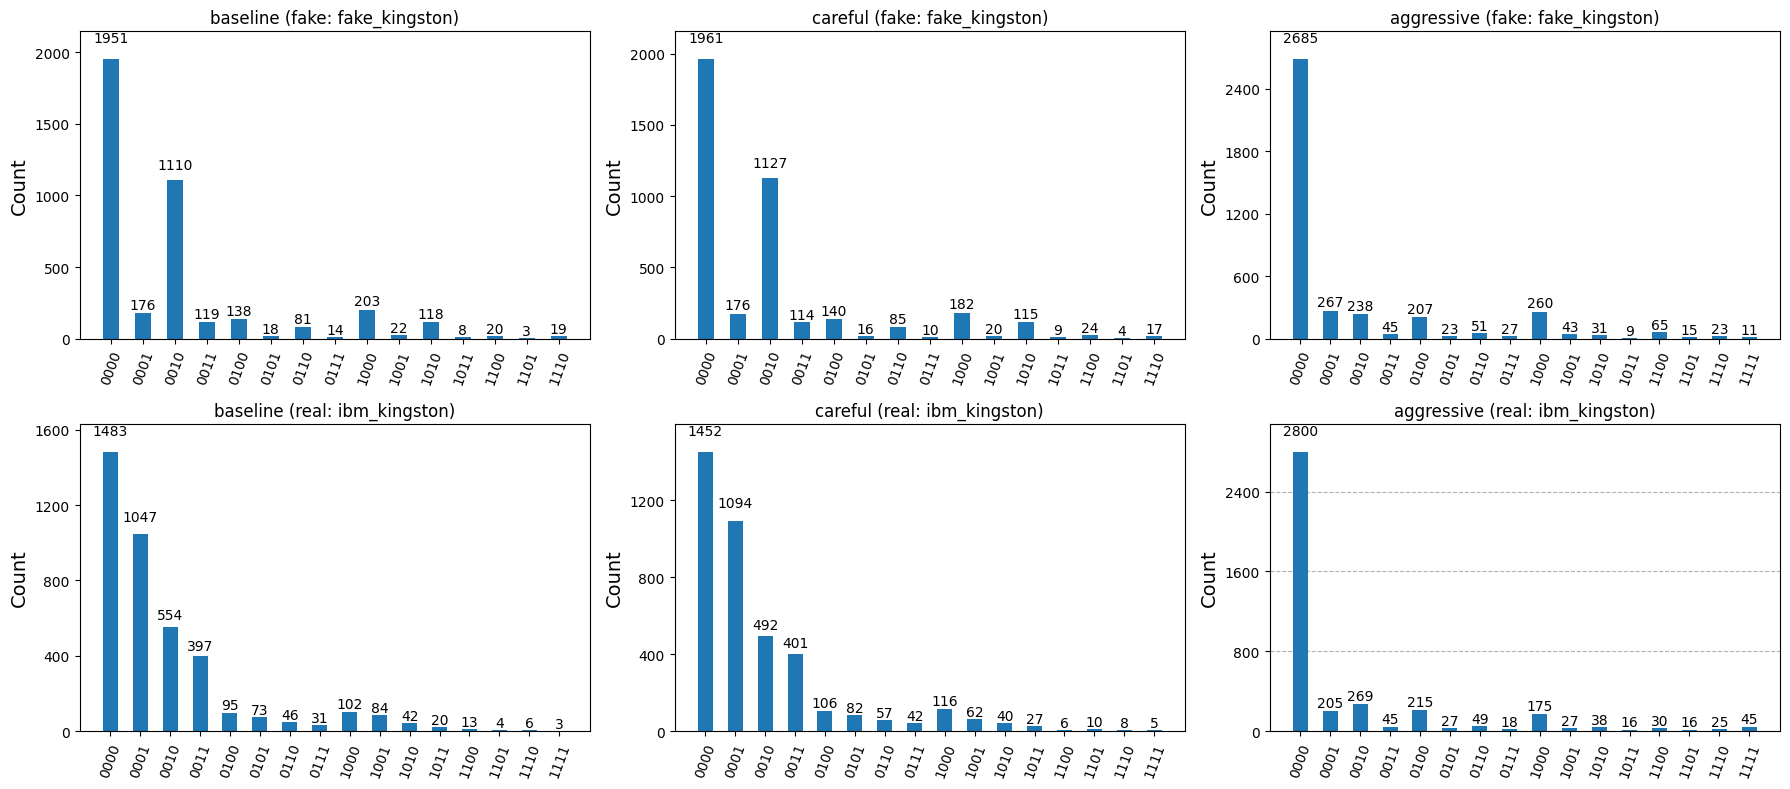

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for col, (name, circ) in enumerate(versions.items()):
    plot_histogram(fake_results[name]["counts"], ax=axes[0][col])
    axes[0][col].set_title(f"{name} (fake: {fake_backend.name})")

    plot_histogram(real_results[name]["counts"], ax=axes[1][col])
    axes[1][col].set_title(f"{name} (real: {real_backend.name})")

plt.tight_layout()
plt.show()

## 8. The Circuits of all 3: Baseline, teleport_reduce, and full_reduce

Baseline circuit:


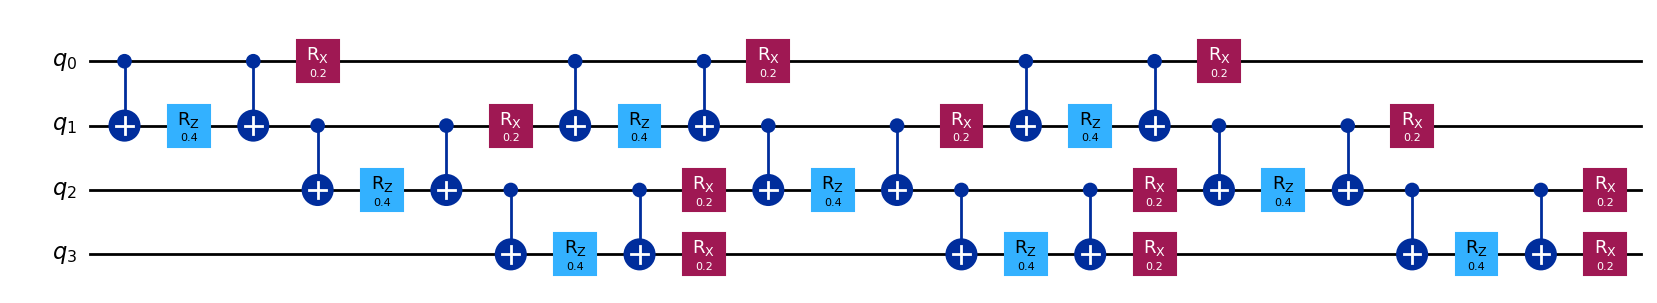

Careful (teleport_reduce) circuit:


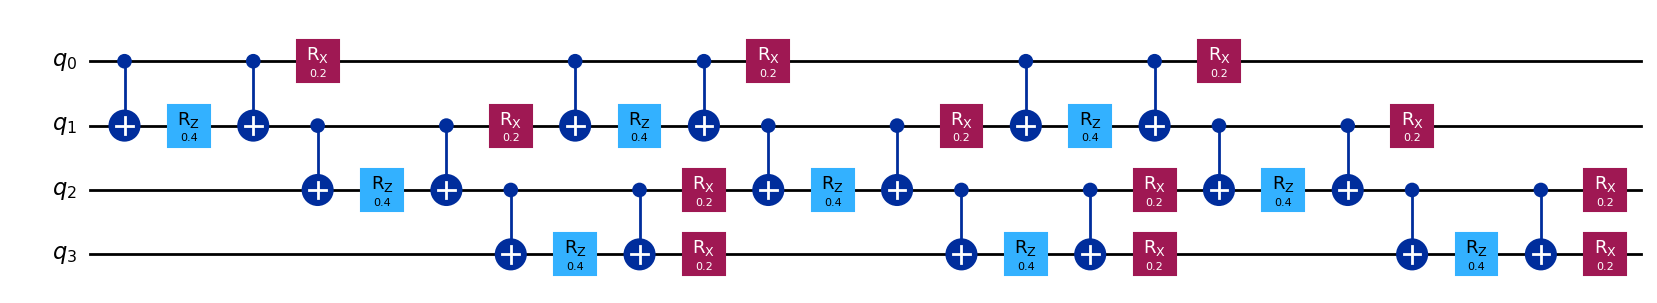

Aggressive (full_reduce) circuit:


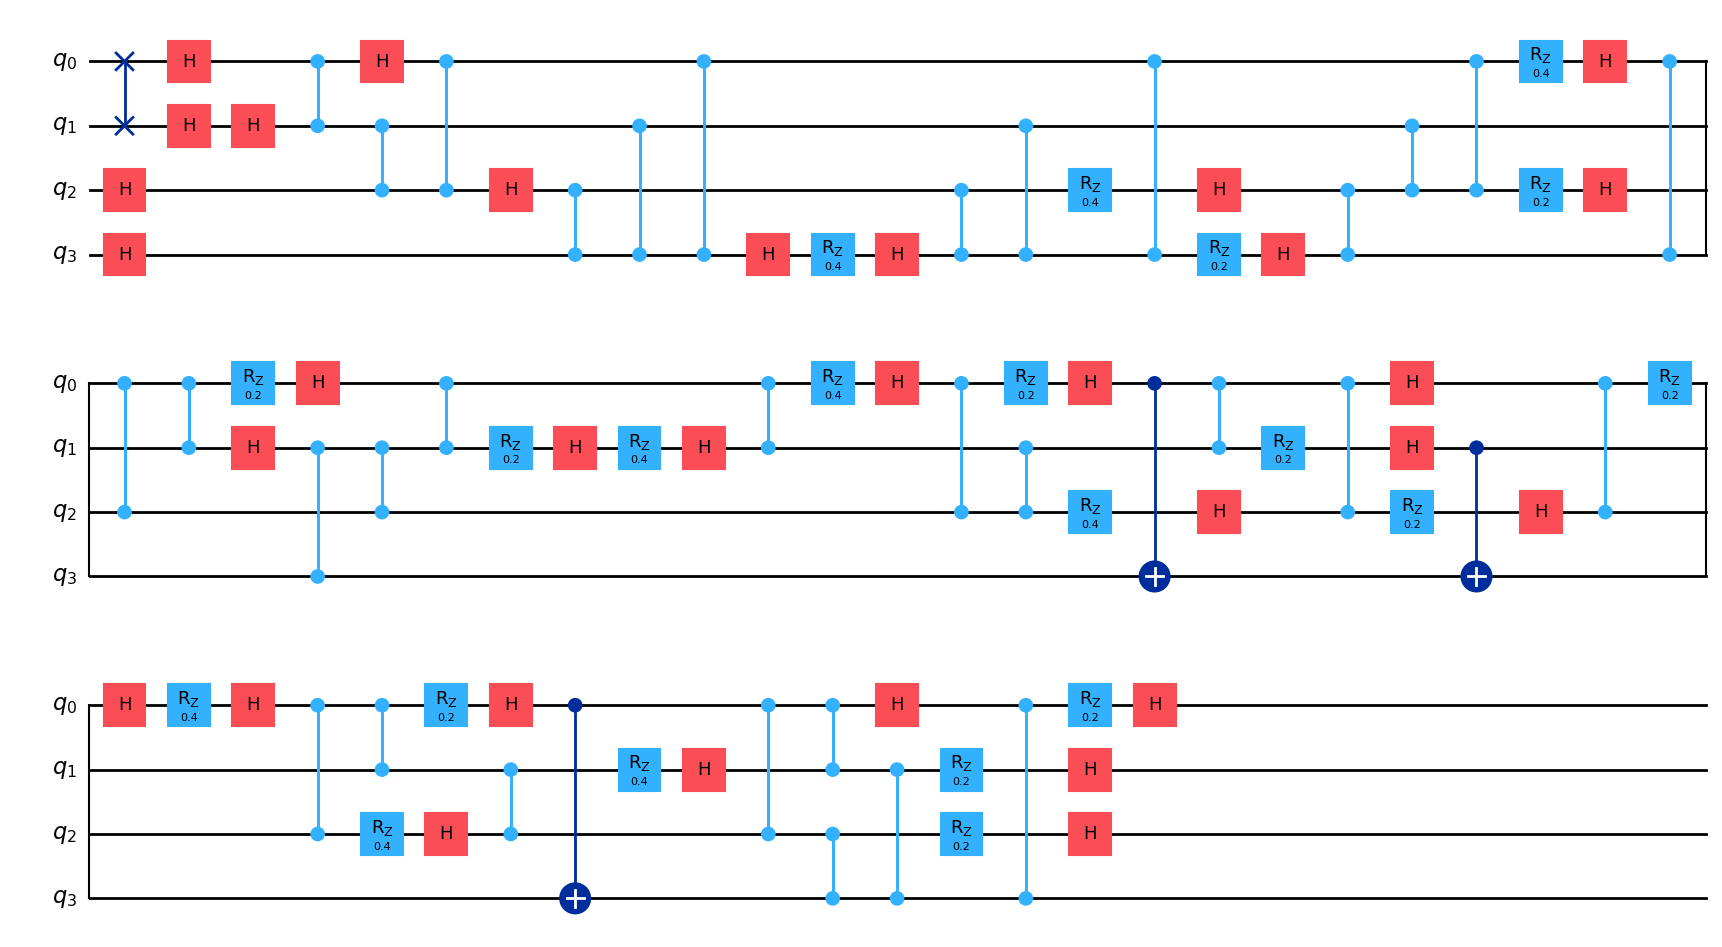

In [ ]:
print("Baseline circuit:")
display(qc_baseline.draw("mpl"))

print("Careful (teleport_reduce) circuit:")
display(qc_careful.draw("mpl"))

print("Aggressive (full_reduce) circuit:")
display(qc_aggressive.draw("mpl"))

## 9. Comparison graphs: real vs. fake, across Total Gates, Two-Qubit Gates, T-Count, and Depth\n\nSame colorful bar-graph structure as the original pre-flight comparison, now split side-by-side for fake vs. real so both are visible in one figure — useful for a clean GitHub write-up.

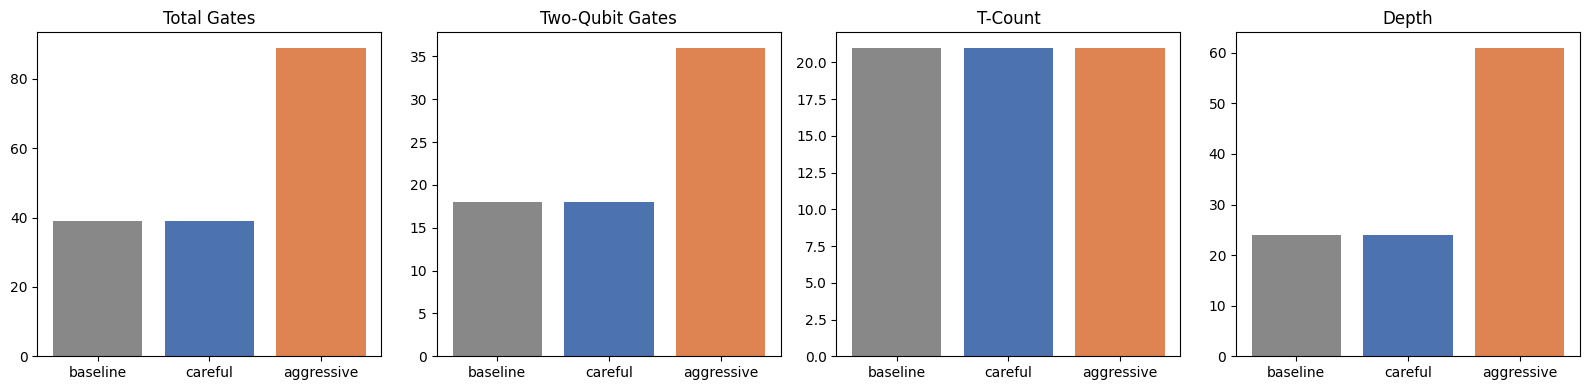

In [ ]:
_names = list(versions.keys())
_metrics_list = [circuit_metrics(versions[n]) for n in _names]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, key, title in zip(
    axes,
    ["total_gates", "two_qubit_gates", "tcount", "depth"],
    ["Total Gates", "Two-Qubit Gates", "T-Count", "Depth"],
):
    values = [m[key] for m in _metrics_list]
    ax.bar(_names, values, color=["#888888", "#4C72B0", "#DD8452"])
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Why did we see that?

---

| Method | What it optimizes for | Effect on my circuit | Why |
|---|---|---|---|
| **`full_reduce`** | spider count / T-count | ~3x gate blowup | Destroys the geometric locality my CNOT-cheapness depended on;<br>extraction (Gaussian elimination) pays for the added entanglement in CNOTs |
| **`teleport_reduce`** | merging matching phase gates only | no change vs. baseline | My circuit has no repeated matching phase angles for it to merge |

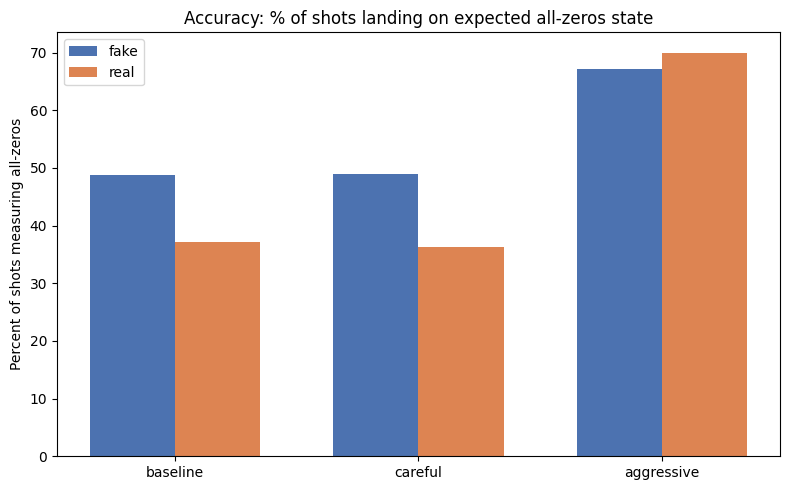

In [ ]:
def all_zeros_accuracy(counts, num_qubits, shots):
    hits = 0
    for bitstring, n in counts.items():
        if bitstring.replace(" ", "") == "0" * num_qubits:
            hits += n
    return 100.0 * hits / shots

fig, ax = plt.subplots(figsize=(8, 5))

fake_acc = [all_zeros_accuracy(fake_results[n]["counts"], num_qubits, shots_per_run) for n in _names]
real_acc = [all_zeros_accuracy(real_results[n]["counts"], num_qubits, shots_per_run) for n in _names]

x = np.arange(len(_names))
width = 0.35
ax.bar(x - width/2, fake_acc, width, label="fake", color="#4C72B0")
ax.bar(x + width/2, real_acc, width, label="real", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(_names)
ax.set_ylabel("Percent of shots measuring all-zeros")
ax.set_title("Accuracy: % of shots landing on expected all-zeros state")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# check this one
qubit_counts = [5, 10, 15, 20]

fake_backend_multi = FakeKingston()
service = QiskitRuntimeService()
real_backend_multi = service.backend("ibm_kingston")

for nq in qubit_counts:
    print(f"Running {nq} qubits...")
    versions_nq = build_versions_for(nq, J, g, dt, steps)

    fake_results_nq = run_versions_on_backend(versions_nq, fake_backend_multi, shots=shots_per_run)
    real_results_nq = run_versions_on_backend(versions_nq, real_backend_multi, shots=shots_per_run)

    fake_acc_nq = {
        name: all_zeros_accuracy(fake_results_nq[name]["counts"], nq, shots_per_run)
        for name in versions_nq
    }
    real_acc_nq = {
        name: all_zeros_accuracy(real_results_nq[name]["counts"], nq, shots_per_run)
        for name in versions_nq
    }

    labels = list(versions_nq.keys())
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(x - width/2, [fake_acc_nq[l] for l in labels], width, label="Fake")
    ax.bar(x + width/2, [real_acc_nq[l] for l in labels], width, label="Real")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"Accuracy of {nq} qubits: Fake vs Real")
    ax.legend()
    plt.tight_layout()
    plt.show()

print("Done.")

NameError: name 'FakeKingston' is not defined

--- Building and reducing circuits for 5 qubits ---


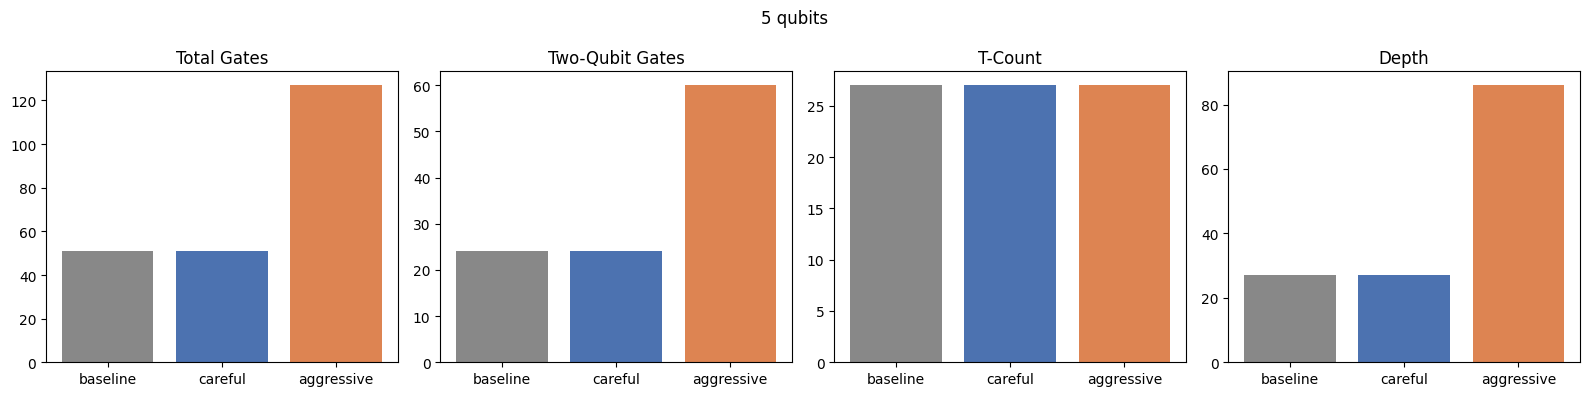

--- Building and reducing circuits for 10 qubits ---


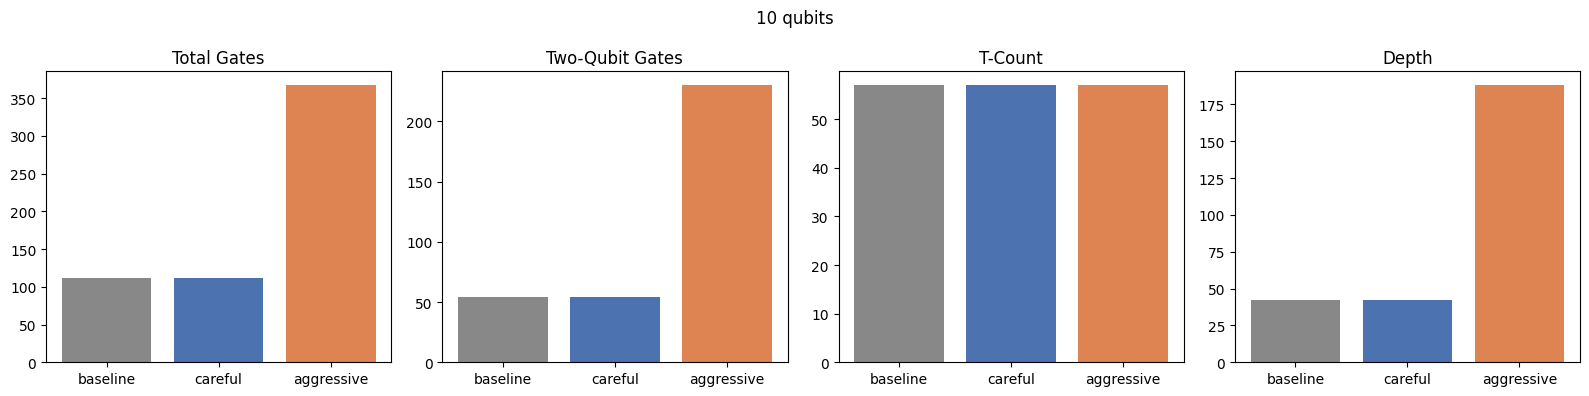

--- Building and reducing circuits for 15 qubits ---


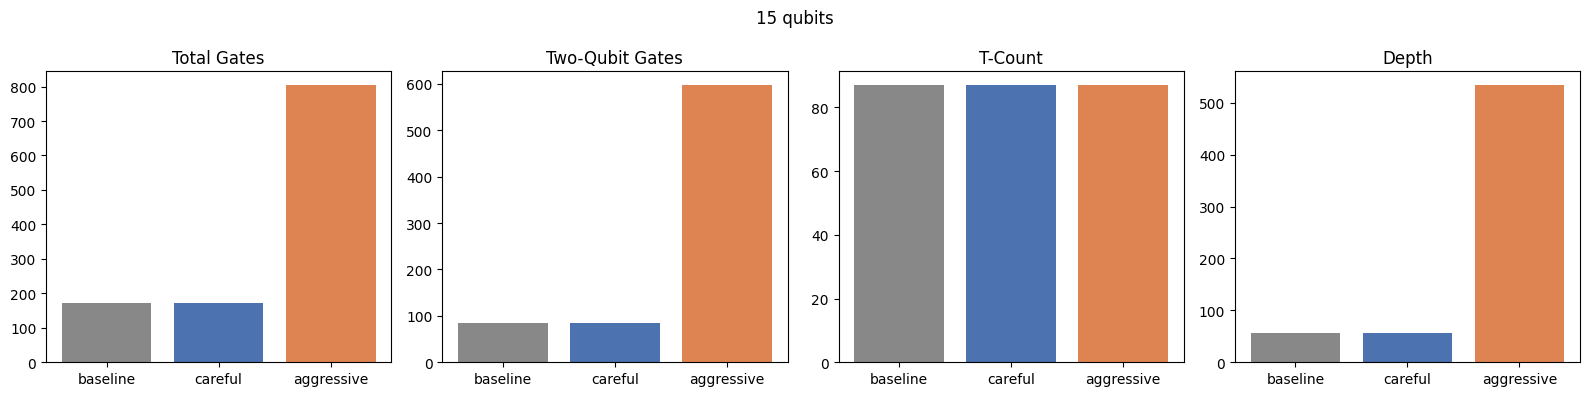

--- Building and reducing circuits for 20 qubits ---


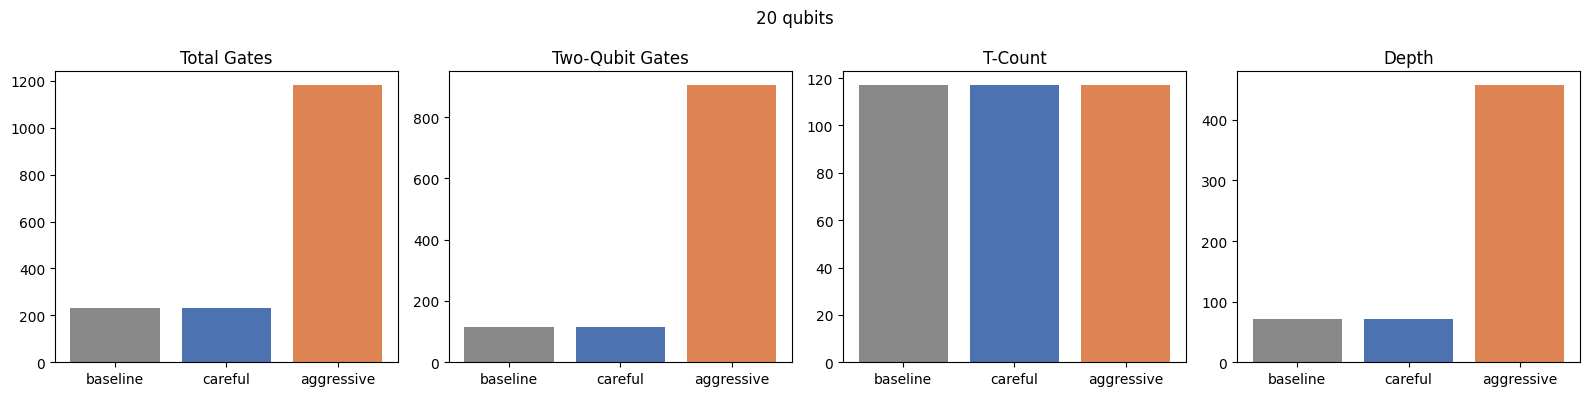

In [ ]:
def build_versions_for(num_qubits, J=1.0, g=0.5, dt=0.2, steps=3):
    baseline = build_tfim_trotter_circuit(num_qubits, J, g, dt, steps)
    careful = teleport_reduce_circuit(baseline, baseline)
    aggressive = full_reduce_circuit(baseline, baseline)
    return {
        "baseline": baseline,
        "careful": careful,
        "aggressive": aggressive,
    }

qubit_counts = [5, 10, 15, 20]

for nq in qubit_counts:
    print(f"--- Building and reducing circuits for {nq} qubits ---")
    versions_nq = build_versions_for(nq, J=J, g=g, dt=dt, steps=steps)

    _names_nq = list(versions_nq.keys())
    _metrics_list_nq = [circuit_metrics(versions_nq[n]) for n in _names_nq]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, key, title in zip(
        axes,
        ["total_gates", "two_qubit_gates", "tcount", "depth"],
        ["Total Gates", "Two-Qubit Gates", "T-Count", "Depth"],
    ):
        values = [m[key] for m in _metrics_list_nq]
        ax.bar(_names_nq, values, color=["#888888", "#4C72B0", "#DD8452"])
        ax.set_title(title)
    fig.suptitle(f"{nq} qubits")
    plt.tight_layout()
    plt.show()